In [14]:
# =============================================================================
# Notebook 01 — EDA Faturamento (Painel 32)
# =============================================================================

import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from datetime import datetime, timedelta
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# --- Carrega .env procurando em varios locais ---
candidatos_env = [
    Path('../.env'),
    Path('../../.env'),
    Path('../workers/.env'),
    Path('C:/ml_workspace/.env'),
    Path('C:/ml_workspace/workers/.env'),
]
carregado = False
for p in candidatos_env:
    if p.exists():
        load_dotenv(p)
        print(f"OK .env carregado de: {p.resolve()}")
        carregado = True
        break

if not carregado:
    print("AVISO: nenhum .env encontrado nos caminhos padrao.")
    print("   Sera necessario preencher as credenciais manualmente abaixo.")

# --- Le do .env com os nomes DB_* (padrao do projeto) ---
pg_host = os.getenv('DB_HOST')
pg_port = os.getenv('DB_PORT', '5432')
pg_db   = os.getenv('DB_NAME')
pg_user = os.getenv('DB_USER')
pg_pass = os.getenv('DB_PASSWORD')

print(f"\nVariaveis lidas:")
print(f"  DB_HOST:     {pg_host}")
print(f"  DB_PORT:     {pg_port}")
print(f"  DB_NAME:     {pg_db}")
print(f"  DB_USER:     {pg_user}")
print(f"  DB_PASSWORD: {'(preenchida)' if pg_pass else '(VAZIA)'}")

# --- Conecta ---
conn = psycopg2.connect(
    host=pg_host,
    port=pg_port,
    database=pg_db,
    user=pg_user,
    password=pg_pass,
)
print(f"\nConectado ao PostgreSQL com sucesso!")

# --- FALLBACK: se alguma variavel esta None, usa valores fixos aqui ---
# Descomente e preencha se o .env nao funcionar
# pg_host = 'localhost'
# pg_port = '5432'
# pg_db   = 'seu_banco'
# pg_user = 'seu_usuario'
# pg_pass = 'sua_senha'

# --- Conecta ---
conn = psycopg2.connect(
    host=pg_host,
    port=pg_port,
    database=pg_db,
    user=pg_user,
    password=pg_pass,
)
print(f"\nConectado ao PostgreSQL com sucesso!")

OK .env carregado de: C:\ml_workspace\.env

Variaveis lidas:
  DB_HOST:     localhost
  DB_PORT:     5432
  DB_NAME:     postgres
  DB_USER:     postgres
  DB_PASSWORD: (preenchida)

Conectado ao PostgreSQL com sucesso!

Conectado ao PostgreSQL com sucesso!


In [15]:
# =============================================================================
# Visão geral — dimensoes e composicao
# =============================================================================

q = """
    SELECT
        COUNT(*)                          AS total_linhas,
        COUNT(DISTINCT nr_atendimento)    AS atendimentos,
        COUNT(DISTINCT dt_entrada)        AS dias,
        MIN(dt_entrada)                   AS dt_min,
        MAX(dt_entrada)                   AS dt_max,
        ROUND(SUM(vl_produzido)::numeric, 2) AS vl_total,
        ROUND(AVG(vl_produzido)::numeric, 2) AS vl_medio_item
    FROM public.ml_faturamento
"""
visao = pd.read_sql(q, conn)
print(visao.T)
print(f"\nMedia de atendimentos/dia: {visao.atendimentos[0] / visao.dias[0]:.1f}")
print(f"Faturamento medio/dia: R$ {visao.vl_total[0] / visao.dias[0]:,.2f}")

                          0
total_linhas        3224734
atendimentos         310763
dias                    834
dt_min           2024-01-01
dt_max           2026-04-13
vl_total       346868017.73
vl_medio_item        107.57

Media de atendimentos/dia: 372.6
Faturamento medio/dia: R$ 415,908.89


In [16]:
# =============================================================================
# Carrega a view diaria pronta (construida no DDL)
# =============================================================================

df = pd.read_sql("""
    SELECT *
    FROM public.vw_faturamento_diario
    ORDER BY data
""", conn)

df['data'] = pd.to_datetime(df['data'])
df = df.set_index('data').asfreq('D')

# Preenche dias sem movimento com 0 (improvavel em hospital, mas protege)
cols_valor = [c for c in df.columns if c.startswith('vl_')] + ['qt_atendimentos', 'qt_itens']
df[cols_valor] = df[cols_valor].fillna(0)

print(f"Shape: {df.shape}")
print(f"\nPrimeiras 3 linhas:")
print(df.head(3))
print(f"\nEstatisticas do vl_total:")
print(df['vl_total'].describe().apply(lambda x: f"R$ {x:,.2f}"))

Shape: (834, 19)

Primeiras 3 linhas:
            qt_atendimentos  qt_itens   vl_total  vl_materiais  \
data                                                             
2024-01-01              227      7053  637703.24     257364.47   
2024-01-02              444      5013  349303.29     109875.07   
2024-01-03              438      4498  357912.60     116779.67   

            vl_medicamentos  vl_procedimentos  vl_diarias  vl_taxas  \
data                                                                  
2024-01-01         59561.59               0.0   115564.07  12706.22   
2024-01-02         37979.64               0.0    39794.77  17452.17   
2024-01-03         40078.38               0.0    16037.00  15242.61   

            vl_honorarios  vl_laboratorio  vl_radiologia  vl_sadt   vl_opme  \
data                                                                          
2024-01-01       73519.86        12201.51       17765.05  4426.07      0.00   
2024-01-02       48312.04        17117

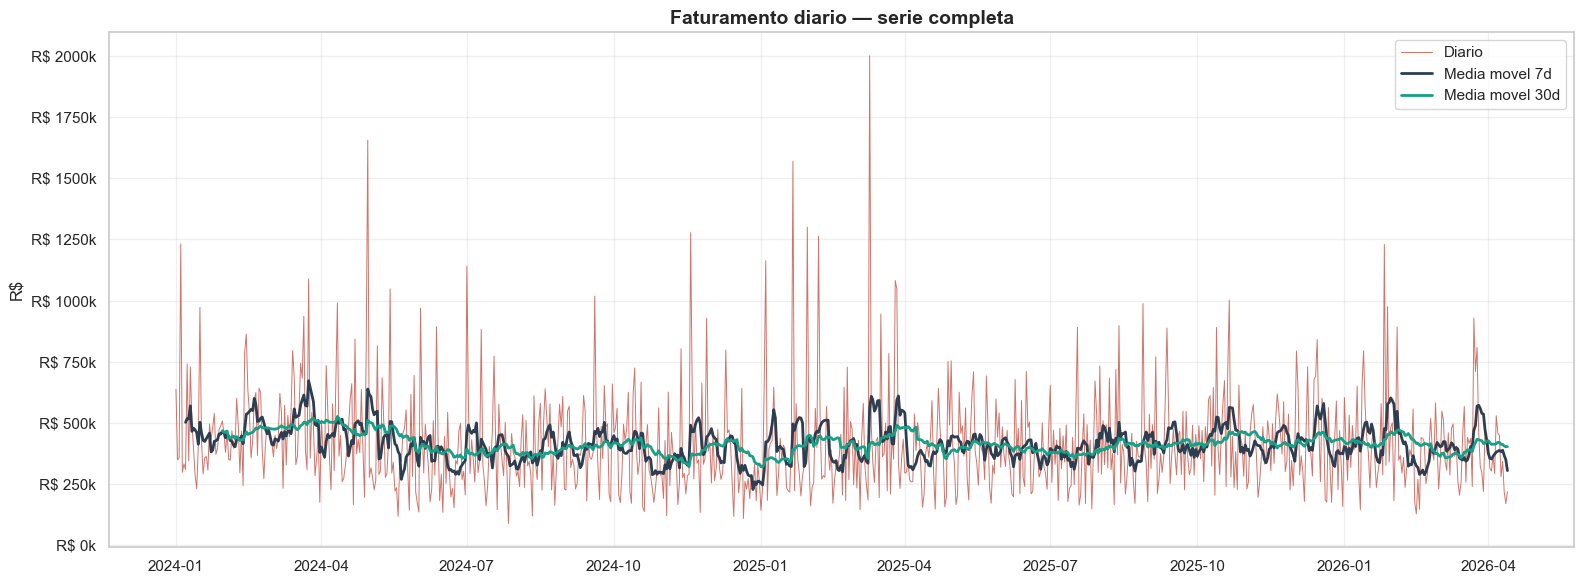

Dias com vl_total = 0: 0
Dias com vl_total muito baixo (<R$ 10k): 0


In [17]:
# =============================================================================
# Faturamento total diario ao longo do tempo
# =============================================================================

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df['vl_total'], linewidth=0.7, color='#c0392b', alpha=0.7, label='Diario')
ax.plot(df.index, df['vl_total'].rolling(7).mean(), linewidth=2, color='#2c3e50', label='Media movel 7d')
ax.plot(df.index, df['vl_total'].rolling(30).mean(), linewidth=2, color='#16a085', label='Media movel 30d')

ax.set_title('Faturamento diario — serie completa', fontsize=14, fontweight='bold')
ax.set_ylabel('R$')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Dias com vl_total = 0: {(df['vl_total'] == 0).sum()}")
print(f"Dias com vl_total muito baixo (<R$ 10k): {(df['vl_total'] < 10000).sum()}")

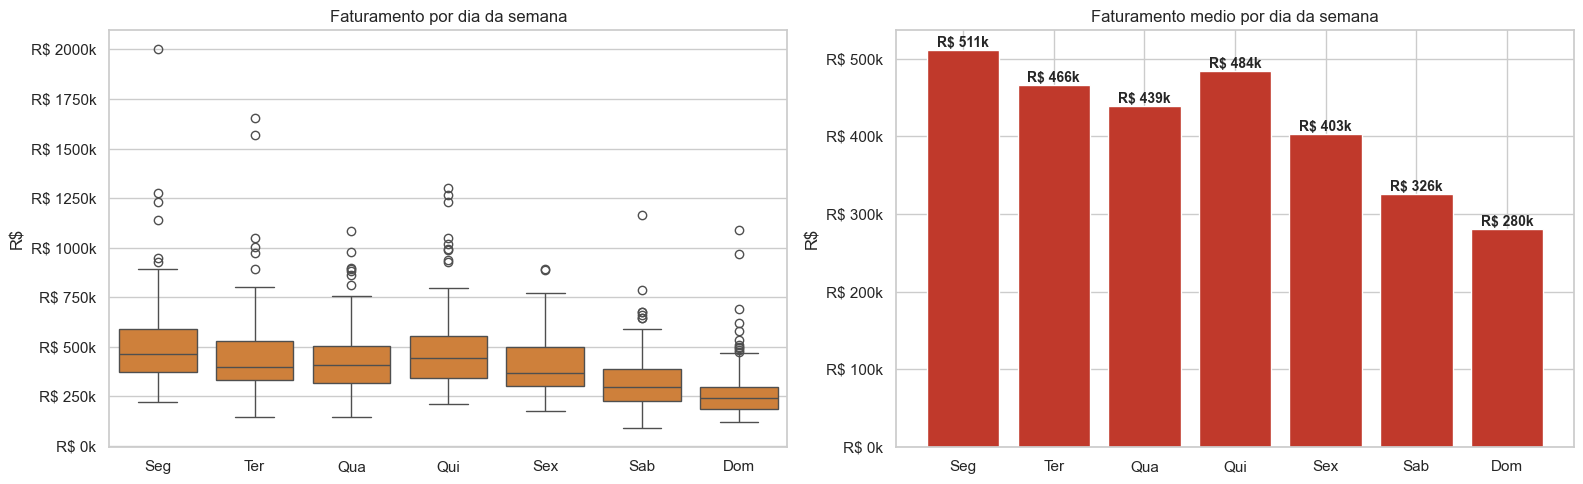

In [18]:
# =============================================================================
# Sazonalidade por dia da semana
# =============================================================================

df['dia_semana'] = df.index.dayofweek
df['nome_dia'] = df.index.day_name()

ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ptbr = {'Monday':'Seg', 'Tuesday':'Ter', 'Wednesday':'Qua', 'Thursday':'Qui', 'Friday':'Sex', 'Saturday':'Sab', 'Sunday':'Dom'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
df_box = df[['vl_total', 'nome_dia']].copy()
df_box['dia_pt'] = df_box['nome_dia'].map(ptbr)
ordem_pt = [ptbr[d] for d in ordem_dias]
sns.boxplot(data=df_box, x='dia_pt', y='vl_total', order=ordem_pt, ax=axes[0], color='#e67e22')
axes[0].set_title('Faturamento por dia da semana')
axes[0].set_xlabel('')
axes[0].set_ylabel('R$')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))

# Medias
medias = df.groupby('nome_dia')['vl_total'].mean().reindex(ordem_dias)
bars = axes[1].bar(ordem_pt, medias.values, color='#c0392b')
axes[1].set_title('Faturamento medio por dia da semana')
axes[1].set_ylabel('R$')
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
for bar, v in zip(bars, medias.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v, f'R$ {v/1000:.0f}k',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

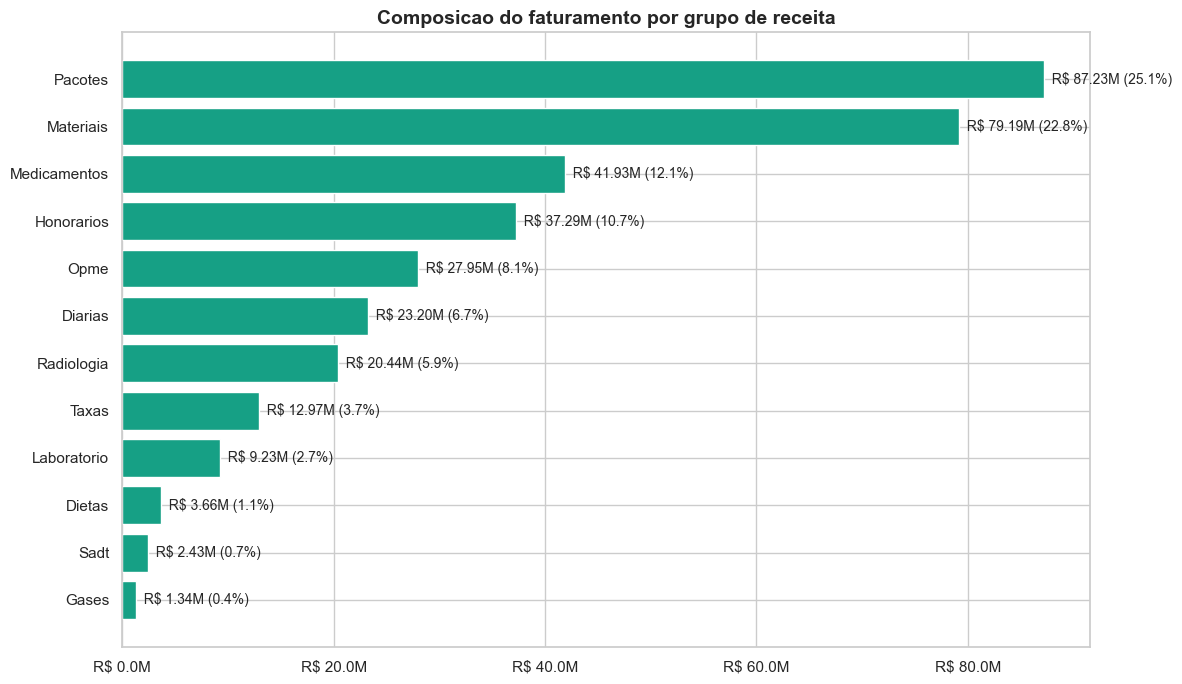


Top 5 grupos (concentracao):
  78.9% do faturamento


In [19]:
# =============================================================================
# Breakdown por grupo de receita
# =============================================================================

grupos = ['vl_materiais', 'vl_medicamentos', 'vl_procedimentos', 'vl_diarias',
          'vl_taxas', 'vl_honorarios', 'vl_laboratorio', 'vl_radiologia',
          'vl_sadt', 'vl_opme', 'vl_gases', 'vl_dietas', 'vl_pacotes', 'vl_extras']

totais = df[grupos].sum().sort_values(ascending=True)
totais_nz = totais[totais > 0]
pcts = totais_nz / totais_nz.sum() * 100

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(totais_nz.index.str.replace('vl_', '').str.title(),
               totais_nz.values, color='#16a085')
ax.set_title('Composicao do faturamento por grupo de receita', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f}M'))
for bar, val, pct in zip(bars, totais_nz.values, pcts):
    ax.text(val, bar.get_y() + bar.get_height()/2,
            f'  R$ {val/1_000_000:.2f}M ({pct:.1f}%)',
            va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nTop 5 grupos (concentracao):")
print(f"  {pcts.sort_values(ascending=False).head(5).sum():.1f}% do faturamento")

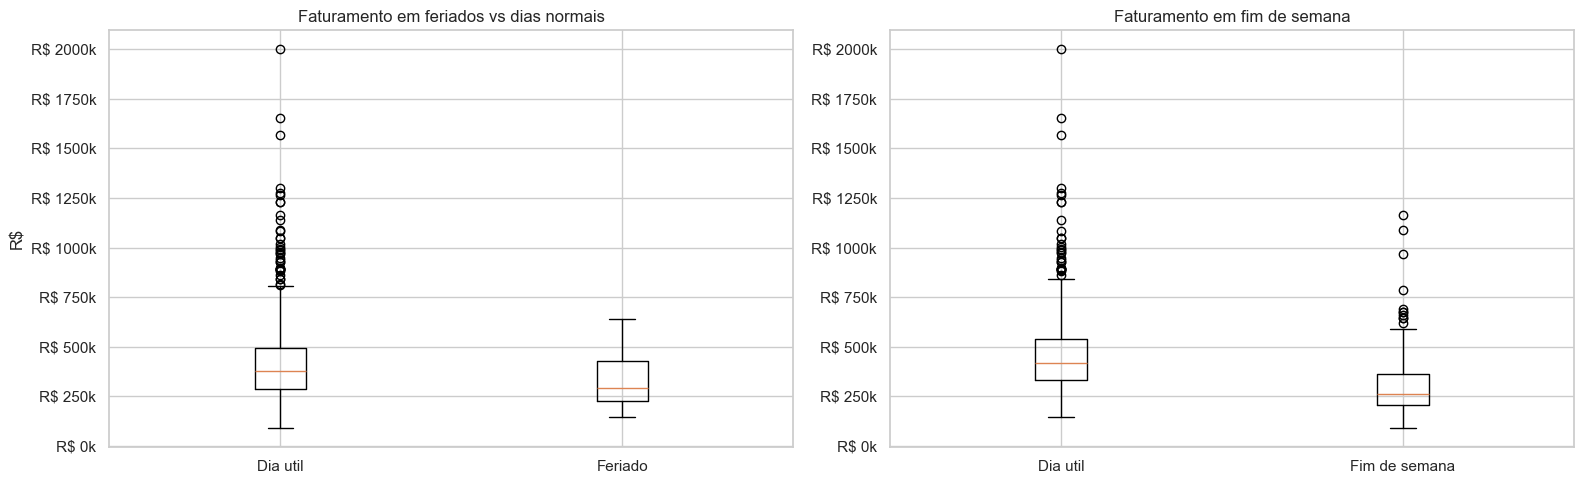


Faturamento medio:
  Dia util normal:     R$ 462,759.85
  Feriado:             R$ 344,645.06  (-25.5%)
  Fim de semana:       R$ 302,991.42  (-34.5%)


In [20]:
# =============================================================================
# Efeito de feriados e fins de semana no faturamento
# =============================================================================

import holidays

anos = list(range(df.index.year.min(), df.index.year.max() + 1))
feriados_df = holidays.Brazil(years=anos, subdiv='DF')

df['is_feriado'] = df.index.to_series().apply(lambda d: d.date() in feriados_df).astype(int)
df['is_fim_semana'] = (df.index.dayofweek >= 5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Feriado vs nao-feriado
dados_f = [
    df[df['is_feriado']==0]['vl_total'].values,
    df[df['is_feriado']==1]['vl_total'].values,
]
axes[0].boxplot(dados_f, labels=['Dia util', 'Feriado'])
axes[0].set_title('Faturamento em feriados vs dias normais')
axes[0].set_ylabel('R$')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))

# Fim de semana
dados_fs = [
    df[df['is_fim_semana']==0]['vl_total'].values,
    df[df['is_fim_semana']==1]['vl_total'].values,
]
axes[1].boxplot(dados_fs, labels=['Dia util', 'Fim de semana'])
axes[1].set_title('Faturamento em fim de semana')
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))

plt.tight_layout()
plt.show()

# Numeros
med_util = df[(df['is_feriado']==0) & (df['is_fim_semana']==0)]['vl_total'].mean()
med_ferd = df[df['is_feriado']==1]['vl_total'].mean() if (df['is_feriado']==1).any() else 0
med_fimsem = df[df['is_fim_semana']==1]['vl_total'].mean()

print(f"\nFaturamento medio:")
print(f"  Dia util normal:     R$ {med_util:,.2f}")
print(f"  Feriado:             R$ {med_ferd:,.2f}  ({(med_ferd/med_util - 1)*100:+.1f}%)")
print(f"  Fim de semana:       R$ {med_fimsem:,.2f}  ({(med_fimsem/med_util - 1)*100:+.1f}%)")

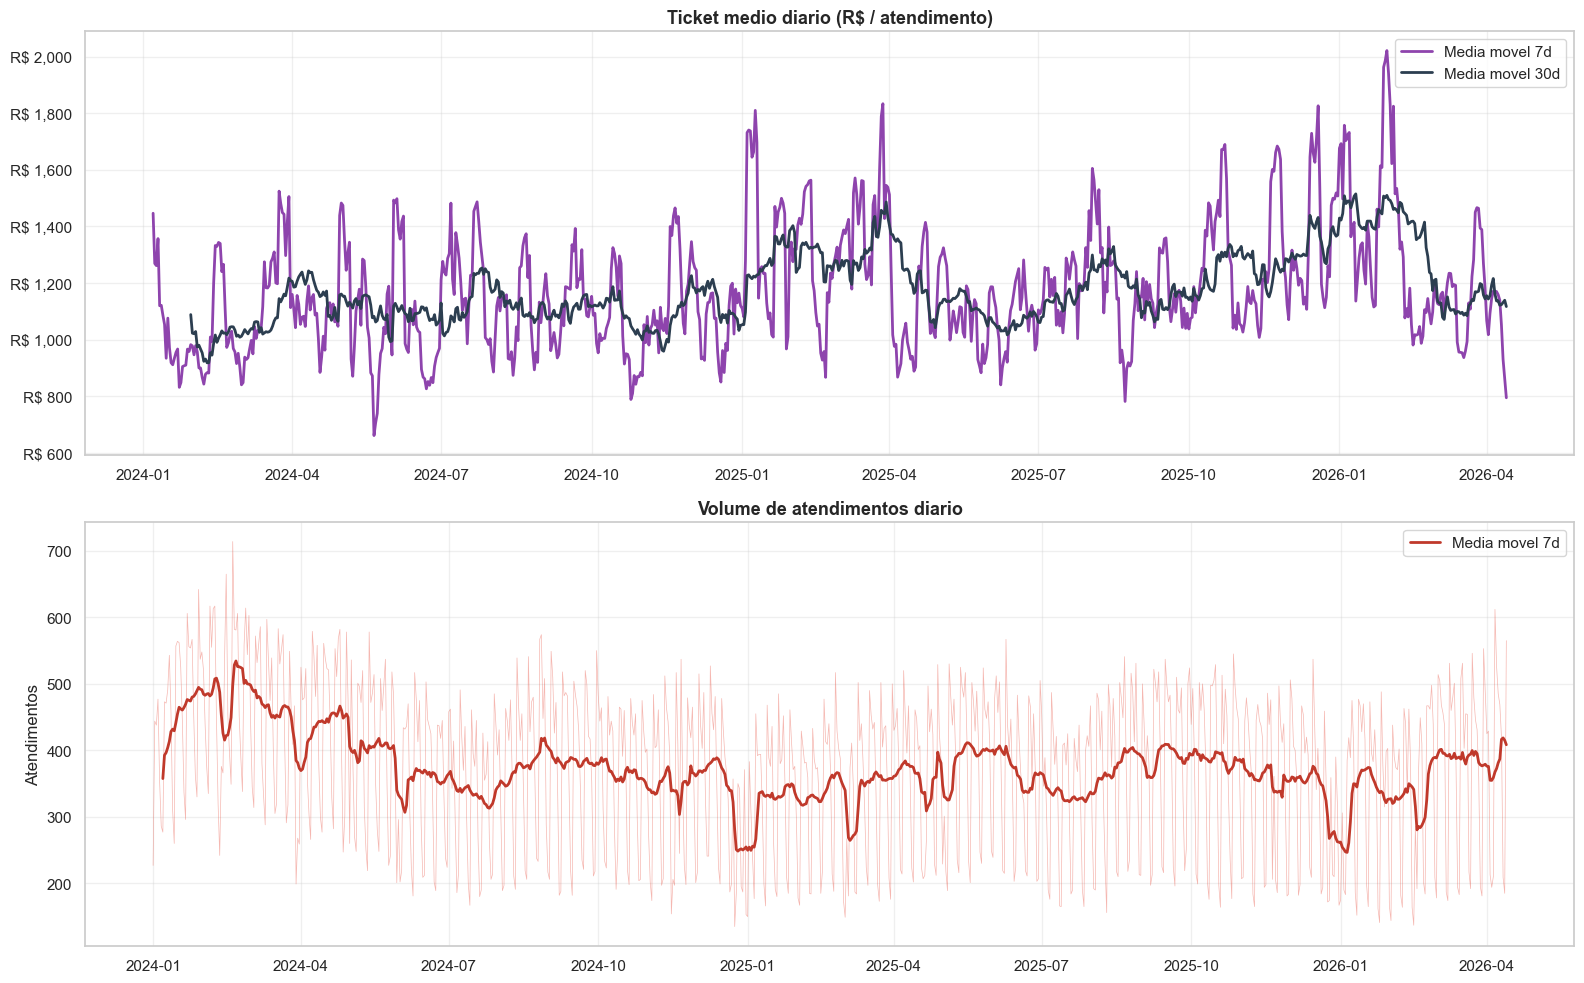

In [21]:
# =============================================================================
# Como o ticket medio evolui — metrica de saude do negocio
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Ticket medio (vl_total / atendimentos)
axes[0].plot(df.index, df['ticket_medio'].rolling(7).mean(), linewidth=2, color='#8e44ad', label='Media movel 7d')
axes[0].plot(df.index, df['ticket_medio'].rolling(30).mean(), linewidth=2, color='#2c3e50', label='Media movel 30d')
axes[0].set_title('Ticket medio diario (R$ / atendimento)', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Volume de atendimentos
axes[1].plot(df.index, df['qt_atendimentos'], linewidth=0.5, color='#e74c3c', alpha=0.4)
axes[1].plot(df.index, df['qt_atendimentos'].rolling(7).mean(), linewidth=2, color='#c0392b', label='Media movel 7d')
axes[1].set_title('Volume de atendimentos diario', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Atendimentos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Correlacoes:
                 vl_total  qt_atendimentos  qt_itens  ticket_medio
vl_total            1.000            0.419     0.779         0.668
qt_atendimentos     0.419            1.000     0.593        -0.319
qt_itens            0.779            0.593     1.000         0.348
ticket_medio        0.668           -0.319     0.348         1.000


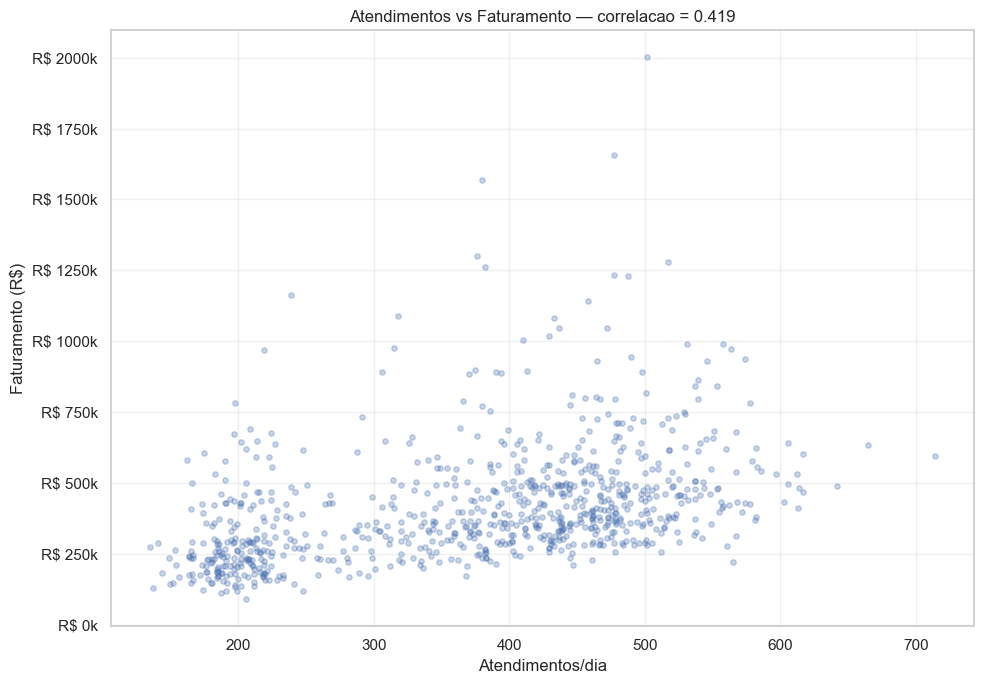

In [22]:
# =============================================================================
# Quao forte e a correlacao atendimentos vs faturamento?
# (Se muito forte, volume e um dos melhores preditores)
# =============================================================================

corr = df[['vl_total', 'qt_atendimentos', 'qt_itens', 'ticket_medio']].corr()
print("Correlacoes:")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df['qt_atendimentos'], df['vl_total'], alpha=0.3, s=15)
ax.set_xlabel('Atendimentos/dia')
ax.set_ylabel('Faturamento (R$)')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
ax.set_title(f'Atendimentos vs Faturamento — correlacao = {corr.loc["vl_total","qt_atendimentos"]:.3f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Top 10 clinicas por faturamento:
  Clinica Médica                 R$ 150,554,406.99
  Cardiologia                    R$  74,839,588.36
  Ortopedia                      R$  32,376,634.90
  Pediatria                      R$  30,216,694.15
  Cirurgica Geral                R$  16,987,708.74
  Ginecologia                    R$  11,991,985.44
  Exames                         R$   9,526,822.98
  Pediátrica                     R$   4,124,770.49
  Emergencista                   R$   3,532,060.48
  Gastro                         R$   2,015,483.38


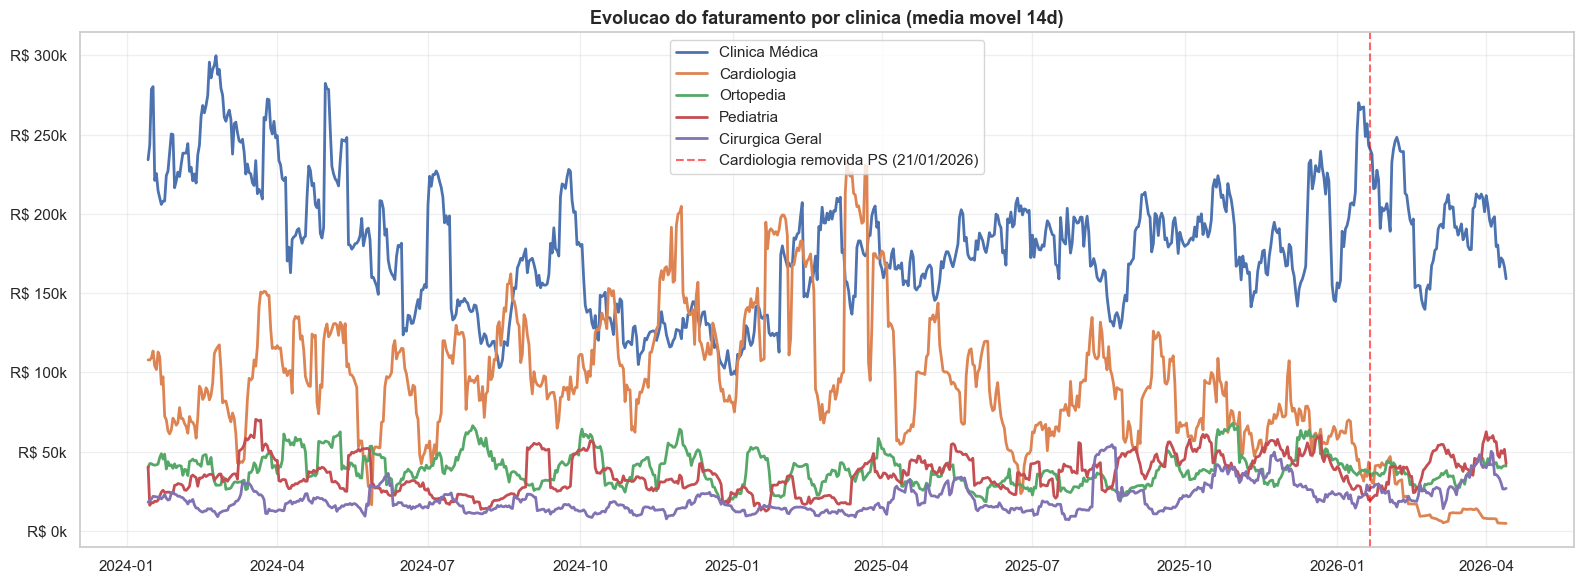

In [23]:
# =============================================================================
# Cardiologia: qual o impacto no faturamento historico?
# (Mesmo raciocinio da flag_clinica_removida do PS Volume)
# =============================================================================

df_clinica = pd.read_sql("""
    SELECT
        data,
        ds_clinica,
        vl_total,
        qt_atendimentos
    FROM public.vw_faturamento_diario_clinica
    WHERE ds_clinica IS NOT NULL
    ORDER BY data
""", conn, parse_dates=['data'])

# Volume agregado por clinica
totais_clinica = df_clinica.groupby('ds_clinica')['vl_total'].sum().sort_values(ascending=False).head(10)
print("Top 10 clinicas por faturamento:")
for c, v in totais_clinica.items():
    print(f"  {c:<30} R$ {v:>14,.2f}")

# Serie temporal das top clinicas
top5 = totais_clinica.head(5).index.tolist()
fig, ax = plt.subplots(figsize=(16, 6))
for clinica in top5:
    serie = df_clinica[df_clinica['ds_clinica'] == clinica].set_index('data')['vl_total']
    serie_mm = serie.rolling(14).mean()
    ax.plot(serie_mm.index, serie_mm.values, linewidth=2, label=clinica)

# Linha vertical na remocao da Cardiologia
ax.axvline(pd.Timestamp('2026-01-21'), color='red', linestyle='--', alpha=0.6,
           label='Cardiologia removida PS (21/01/2026)')
ax.set_title('Evolucao do faturamento por clinica (media movel 14d)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# =============================================================================
# Resumo dos achados — entrada para o Notebook 02 (modelagem)
# =============================================================================

print("="*70)
print("ACHADOS DO EDA")
print("="*70)

medias_semana = df.groupby('nome_dia')['vl_total'].mean()
pico = medias_semana.idxmax()
vale = medias_semana.idxmin()

print(f"""
PERIODO COBERTO:          {df.index.min().date()} a {df.index.max().date()}
TOTAL DE DIAS:            {len(df)}
FATURAMENTO MEDIO/DIA:    R$ {df['vl_total'].mean():,.2f}
DESVIO PADRAO:            R$ {df['vl_total'].std():,.2f}
COEF. VARIACAO:           {df['vl_total'].std()/df['vl_total'].mean()*100:.1f}%

SAZONALIDADE SEMANAL:
  Pico:                   {ptbr.get(pico,pico)} (R$ {medias_semana[pico]:,.2f})
  Vale:                   {ptbr.get(vale,vale)} (R$ {medias_semana[vale]:,.2f})
  Razao pico/vale:        {medias_semana[pico]/medias_semana[vale]:.2f}x

CORRELACAO ATENDIMENTOS x FATURAMENTO:
  {df[['vl_total','qt_atendimentos']].corr().iloc[0,1]:.3f}
  {'(forte - volume e bom preditor)' if abs(df[['vl_total','qt_atendimentos']].corr().iloc[0,1]) > 0.7 else '(moderada)'}

TICKET MEDIO GERAL:       R$ {(df['vl_total'].sum() / df['qt_atendimentos'].sum()):,.2f}
""")

conn.close()

ACHADOS DO EDA

PERIODO COBERTO:          2024-01-01 a 2026-04-13
TOTAL DE DIAS:            834
FATURAMENTO MEDIO/DIA:    R$ 415,908.89
DESVIO PADRAO:            R$ 205,961.69
COEF. VARIACAO:           49.5%

SAZONALIDADE SEMANAL:
  Pico:                   Seg (R$ 511,138.85)
  Vale:                   Dom (R$ 280,277.32)
  Razao pico/vale:        1.82x

CORRELACAO ATENDIMENTOS x FATURAMENTO:
  0.419
  (moderada)

TICKET MEDIO GERAL:       R$ 1,116.03

